# Demo c: Shepp-Logan phantom with interleaved sampling and simulated per-shot non-rigid motion


[Demo C] Loading config...
[Demo C] Initializing runtime...
[Demo C] Loading data and building operators...
[DataLoader] k-space normalized (rms), scale=1.010733e-01


EspiritCalib:   0%|          | 0/100 [00:00<?, ?it/s]

Simulating non-rigid motion fields...
Visualizing non-rigid alpha fields (alpha_x, alpha_y)...
[DEBUG] GN-input consistency check (true alpha, clustered signal/sampling): rel_err=1.148280e-02


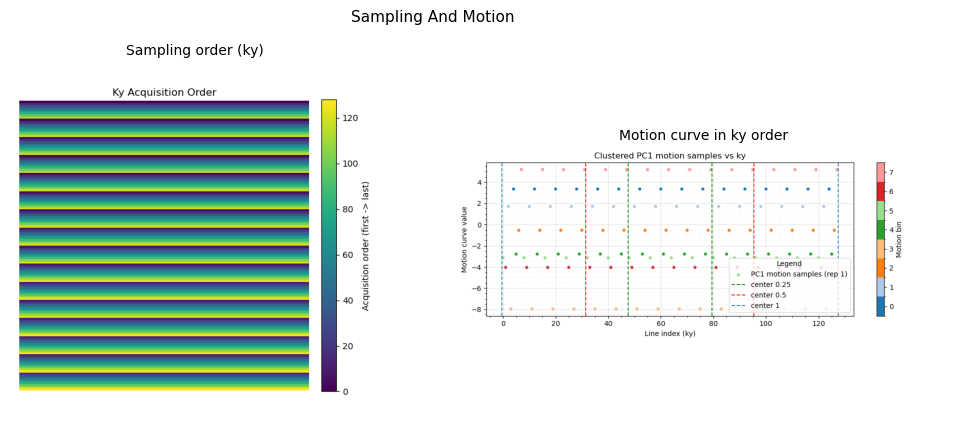

[Demo C] Starting reconstruction...


Resolution level 1/3:   0%|          | 0/10 [00:00<?, ?it/s]

Resolution level 2/3:   0%|          | 0/4 [00:00<?, ?it/s]

Resolution level 3/3:   0%|          | 0/4 [00:00<?, ?it/s]

Elapsed time: 14.84 s


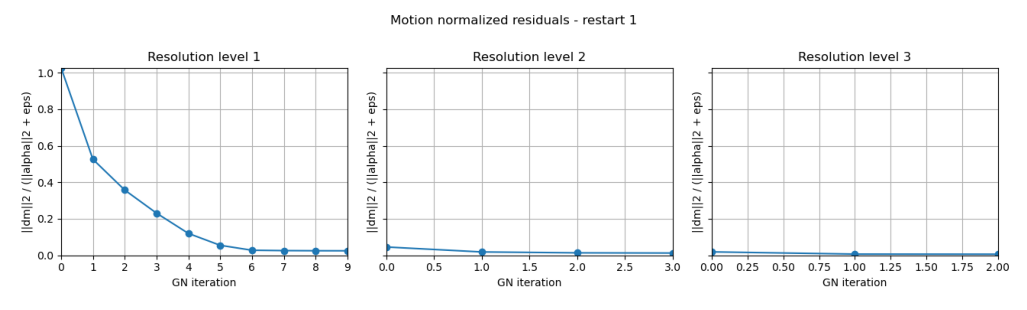

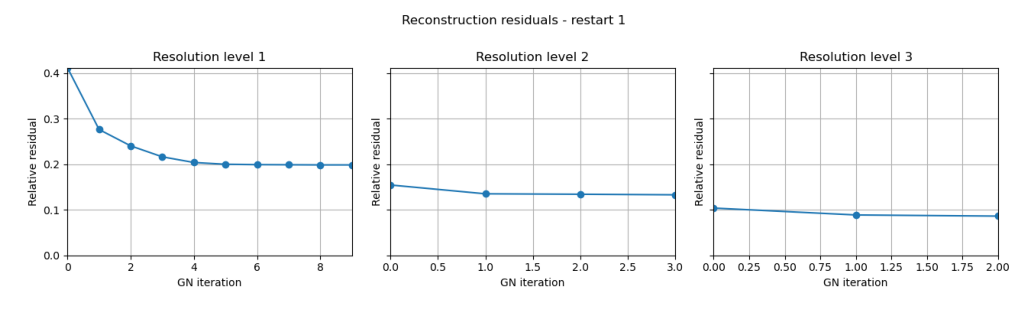

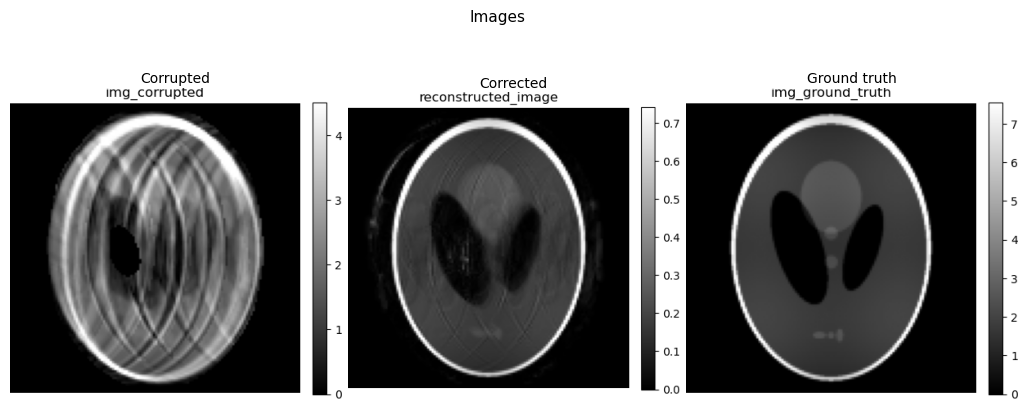

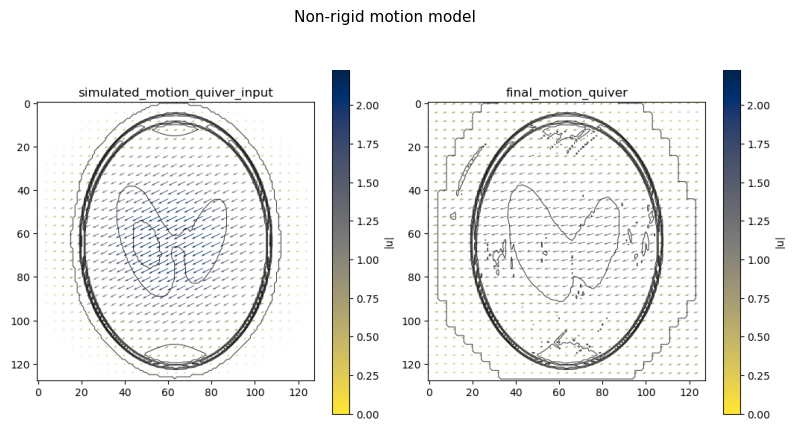

In [1]:
import time

from src.runtime.runtime_config import load_config
from src.preprocessing.DataLoader import DataLoader
from src.reconstruction.JointReconstructor import JointReconstructor
from src.utils.notebook_display import display_input_sampling_motion_panels, display_run_panels
from src.runtime.runtime_setup import initialize_runtime

jupyter_notebook_flag = True

def main():
    print("[Demo C] Loading config...")
    params = load_config(
        data_type="shepp-logan",
        reconstruction_config="config/reconstruction/nonrigid_fast.toml",
        shepp_logan_config="config/shepp_logan.toml",
        sampling_config="config/sampling_simulation/interleaved.toml",
        motion_simulation_config="config/motion_simulation/discrete_nonrigid.toml",
        overrides={
            "jupyter_notebook_flag": jupyter_notebook_flag,
            "print_to_console": not jupyter_notebook_flag,
            "verbose": not jupyter_notebook_flag,
        },
    )

    print("[Demo C] Initializing runtime...")
    sp_device, t_device = initialize_runtime(params)

    print("[Demo C] Loading data and building operators...")
    data = DataLoader(params=params, t_device=t_device, sp_device=sp_device)
    display_input_sampling_motion_panels(
        params,
        has_ground_truth=(
            getattr(params, "motion_simulation_type", None)
            not in {"as-it-is", "no-motion"}
        ),
        jupyter_notebook_flag=params.jupyter_notebook_flag,
    )
    
    print("[Demo C] Starting reconstruction...")
    recon = JointReconstructor(
        data.kspace,
        data.smaps,
        data.sampling_idx,
        motion_signal=data.motion_signal,
        params=params,
        kspace_scale=data.kspace_scale,
        motion_plot_context=getattr(data, "motion_plot_context", None),
    )
    t0 = time.time()
    recon.run()
    print(f"Elapsed time: {time.time() - t0:.2f} s")
    display_run_panels(
        params,
        motion_type=params.motion_type,
        has_ground_truth=(
            getattr(params, "motion_simulation_type", None)
            not in {"as-it-is", "no-motion"}
        ),
        jupyter_notebook_flag=params.jupyter_notebook_flag,
    )


if __name__ == "__main__":
    main()
